# Statistical Testing & Diagnostic Econometric Modeling

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler
from scipy import stats
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_rbi = pd.read_csv("../dataset/clean/after_metrics_calculated/rbi.csv",  parse_dates=["Date"])
df_telecom_sub = pd.read_csv("../dataset/clean/after_metrics_calculated/telecom_sub.csv",  parse_dates=["date"])
df_nfhs = pd.read_csv("../dataset/clean/after_metrics_calculated/nfhs.csv")

# Hypothesis 1: Structural Break in Cash Dependence

## Goal:  Detect and statistically validate a structural change-point marking a significant shift from ATM-based cash reliance toward digital payment adoption.

Why use Chow Test / Piecewise Linear Regression?

The Chow Test and piecewise linear regression are appropriate because they test whether the underlying trend of the cash-to-digital reliance ratio changed significantly at a specific point in time. This allows us to identify and statistically validate a structural break rather than relying only on visual changes in the time series.

<ul>
<li>Chow Test → tests whether the regression relationship before and after a proposed break point is statistically different.</li>
<li>Piecewise Linear Regression → estimates how the trend changed after the break:</li>
<ul>
<li>γ₁ → change in the level</li>
<li>β₂ → change in the slope/trend</li>
</ul>
<li>F-test/p-value → tells you whether the observed change is statistically significant rather than just random fluctuation.</li>
<li>Estimated break point → identifies when the relationship changed</li>
</ul>

#### Step 1- Preparing data for the structural-break / piecewise regression model

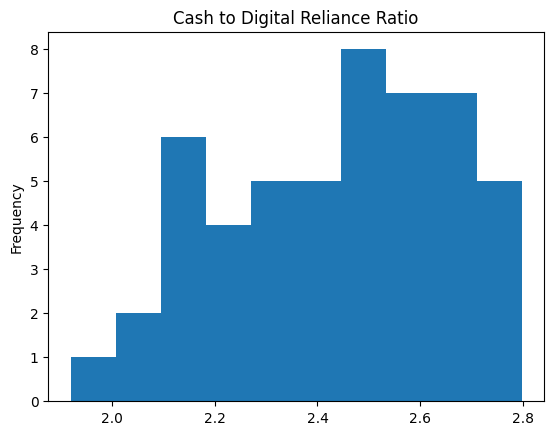

In [3]:
df_rbi["Cash_to_Digital_Reliance_Ratio"].plot(kind="hist")
plt.title("Cash to Digital Reliance Ratio")
plt.show()

In [4]:
df_rbi["R_C2D"] = df_rbi["Cash_to_Digital_Reliance_Ratio"] # Using a short column name to makes regression code easier to read.

# why take the log?
# Reason 1 — Ratios is skewed
# Reason 2 — Percentage interpretation
df_rbi["ln_R_C2D"] = np.log(df_rbi["R_C2D"])

# Create a numerical time index for the regression.
# Each observation is assigned a sequential number (0, 1, 2, ...),
# allowing the model to measure how R_C2D changes over time.
df_rbi["t"] = np.arange(len(df_rbi))

### step -2 Create candidate break points

In [5]:
n = len(df_rbi)

candidate_breaks = range(
    int(n * 0.20),
    int(n * 0.80)
)
candidate_breaks

range(10, 40)

### step - 3 Run the piecewise model for each candidate

In [6]:
results = []

for break_idx in candidate_breaks:

    # Create a copy so each candidate break is tested independently
    temp = df_rbi.copy()

    # Create a dummy variable for the candidate structural break:
    # D = 0 for observations before the break
    # D = 1 for observations from the break onward.
    temp["D"] = (temp["t"] >= break_idx).astype(int)

    # Create an interaction term between time and the break dummy.
    # This allows the regression to estimate whether the trend/slope
    # changes after the candidate break.
    temp["t_after"] = temp["t"] * temp["D"]

    # Fit a segmented (interrupted) time-series regression:
    #
    # ln(R_C2D) = β0 + β1*t + γ1*D + β2*(t*D) + error
    #
    # β1  = trend before the break
    # γ1  = immediate level change at the break
    # β2  = change in slope/trend after the break
    X = temp[["t", "D", "t_after"]]
    X = sm.add_constant(X)

    y = temp["ln_R_C2D"]

    model = sm.OLS(y, X).fit()

    # Test whether the candidate break produces a statistically
    # significant structural change.
    #
    # H0: γ1 = 0 AND β2 = 0
    #      no immediate level change and no change in trend
    #
    # H1: at least one of γ1 or β2 is different from zero
    #     evidence of a structural break.
    test = model.f_test("D = 0, t_after = 0")

    results.append({
        "break_index": break_idx,
        "break_date": temp.loc[break_idx, "Date"],
        "F_statistic": float(test.fvalue),
        "p_value": float(test.pvalue)
    })
results_df  = pd.DataFrame(results)

In [7]:
best_break = results_df.loc[
    results_df["F_statistic"].idxmax()
]
best_break

break_index                     39
break_date     2023-01-01 00:00:00
F_statistic              14.708186
p_value                   0.000012
Name: 29, dtype: object

The candidate-break search identifies January 2023 as the strongest estimated change-point, with evidence of a structural change extending across nearby early-2023 candidate dates.

In [8]:
break_idx = int(best_break["break_index"])

df_rbi["D"] = (df_rbi["t"] >= break_idx).astype(int)
df_rbi["t_after"] = df_rbi["t"] * df_rbi["D"]

X = df_rbi[["t", "D", "t_after"]]
X = sm.add_constant(X)

y = df_rbi["ln_R_C2D"]

final_model = sm.OLS(y, X).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_R_C2D   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     85.63
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           7.59e-19
Time:                        09:33:02   Log-Likelihood:                 95.135
No. Observations:                  50   AIC:                            -182.3
Df Residuals:                      46   BIC:                            -174.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7223      0.012     61.095      0.0

In [9]:
print("Estimated break:", best_break["break_date"])
print("F-statistic:", best_break["F_statistic"])
print("p-value:", best_break["p_value"])

print("\nCoefficients:")
print(model.params)

print("\nConfidence intervals:")
print(model.conf_int())

Estimated break: 2023-01-01 00:00:00
F-statistic: 14.70818600915975
p-value: 1.1527111436684512e-05

Coefficients:
const      0.722332
t          0.007652
D         -0.027791
t_after   -0.001655
dtype: float64

Confidence intervals:
                0         1
const    0.698534  0.746131
t        0.006574  0.008729
D       -0.347269  0.291687
t_after -0.008957  0.005647


The analysis identifies January 2023 as the estimated structural break in the cash-to-digital reliance ratio. The joint Chow test is statistically significant (\(F=14.71,\ p<0.001\)), providing evidence of a structural shift in the relationship. The estimated trend in the ratio, however, remained positive after the break while declining from 0.00765 to approximately 0.00600 per time period. Thus, the results show that cash-to-digital reliance changed over time, but it did not completely reverse or stop being linked to ATM cash usage.

# Hypothesis 2: Urban vs. Rural Gender Parity Significance

### 1. Goal To determine whether the gender gap in digital access is significantly larger in rural areas than in urban areas across the 36 States and Union Territories of India.

The analysis compares the difference between male and female digital access within each state's rural and urban populations.

## Hypothesis
### Null Hypothesis
There is no statistically significant difference between the average rural and urban gender gaps.

### Alternative Hypothesis
There is a statistically significant difference between the average rural and urban gender gaps.

## 3. Why use these testing methods?

Paired Welch's t-test is used because each state/UT provides two related observations—one rural gender gap and one urban gender gap. Comparing them within the same states helps control for differences between states.

Wilcoxon Signed-Rank Test is used as a non-parametric check because the t-test assumes that the differences are reasonably well behaved. The Wilcoxon test does not rely on the same normality assumption and therefore provides a robustness check.

### Step 1 — Calculate the two gender gaps

In [10]:
# Rural gender gap
df_nfhs["Gap_Rural"] = (
    df_nfhs["Men_Internet_pct_rural"]
    - df_nfhs["Women_Internet_pct_rural"]
)

# Urban gender gap
df_nfhs["Gap_Urban"] = (
    df_nfhs["Men_Internet_pct_urban"]
    - df_nfhs["Women_Internet_pct_urban"]
)

### Step 2 — Calculate the rural-vs-urban difference

In [11]:
df_nfhs["Gap_Difference"] = (
    df_nfhs["Gap_Rural"] - df_nfhs["Gap_Urban"]
)

In [12]:
df_nfhs[
    [
        "state_ut",
        "Gap_Rural",
        "Gap_Urban",
        "Gap_Difference"
    ]
]

,state_ut,Gap_Rural,Gap_Urban,Gap_Difference
0,Andaman & Nicobar Islands,13.2,10.5,2.7
1,Andhra Pradesh,26.1,31.2,-5.1
2,Arunachal Pradesh,18.9,16.9,2.0
3,Assam,13.4,18.4,-5.0
4,Bihar,22.4,20.0,2.4
5,Chandigarh,NaN,16.7,NaN
6,Chhattisgarh,29.6,30.9,-1.3
7,Dadra and Nagar Haveli & Daman and Diu,37.5,26.8,10.7
8,Goa,8.3,8.0,0.3
9,Gujarat,30.5,24.0,6.5


Since there is no complete rural–urban pair for Chandigarh. A paired test cannot use that observation.

In [13]:
test_df = df_nfhs.dropna(
    subset=["Gap_Rural", "Gap_Urban"]
).copy()

### Step-3 Run the paired t-test

In [14]:
t_stat, p_value = stats.ttest_rel(
    test_df["Gap_Rural"],
    test_df["Gap_Urban"]
)

print("Paired t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)
print("degrees of freedom:", len(test_df) - 1)

Paired t-test
t-statistic: 3.7914418971955937
p-value: 0.0006056833947491859
degrees of freedom: 33


### Step-4  Calculate the mean difference

In [15]:
mean_difference = test_df["Gap_Difference"].mean()

print("Mean rural gap:", test_df["Gap_Rural"].mean())
print("Mean urban gap:", test_df["Gap_Urban"].mean())
print("Mean difference:", mean_difference)

Mean rural gap: 23.226470588235294
Mean urban gap: 18.93823529411765
Mean difference: 4.288235294117648


### Step-5 Calculate the 95% confidence interval

In [16]:
differences = test_df["Gap_Difference"]

n = len(differences)
mean_diff = differences.mean()
std_diff = differences.std(ddof=1)

se = std_diff / np.sqrt(n)

t_critical = stats.t.ppf(0.975, df=n-1)

ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

print("Mean difference:", mean_diff)
print("95% CI:", (ci_lower, ci_upper))

Mean difference: 4.288235294117648
95% CI: (np.float64(1.9871370466678502), np.float64(6.589333541567445))


### Step -6 Wilcoxon robustness test

In [17]:
w_stat, w_p = stats.wilcoxon(
    test_df["Gap_Rural"],
    test_df["Gap_Urban"]
)

print("Wilcoxon statistic:", w_stat)
print("Wilcoxon p-value:", w_p)

Wilcoxon statistic: 105.0
Wilcoxon p-value: 0.0009978249446350215


The analysis found a statistically significant difference between rural and urban gender gaps in Internet access across the 34 State/UTs with complete observations. The mean gender gap was 23.23 percentage points in rural areas compared with 18.94 percentage points in urban areas, resulting in a mean rural–urban difference of 4.29 percentage points (95% CI: 1.99–6.59). The paired t-test was statistically significant, \(t(33)=3.79, p<0.001\). The Wilcoxon Signed-Rank test produced a consistent result (\(p<0.001\)). Thus, within this dataset, the gender gap in Internet access is significantly larger in rural areas than in urban areas on average.

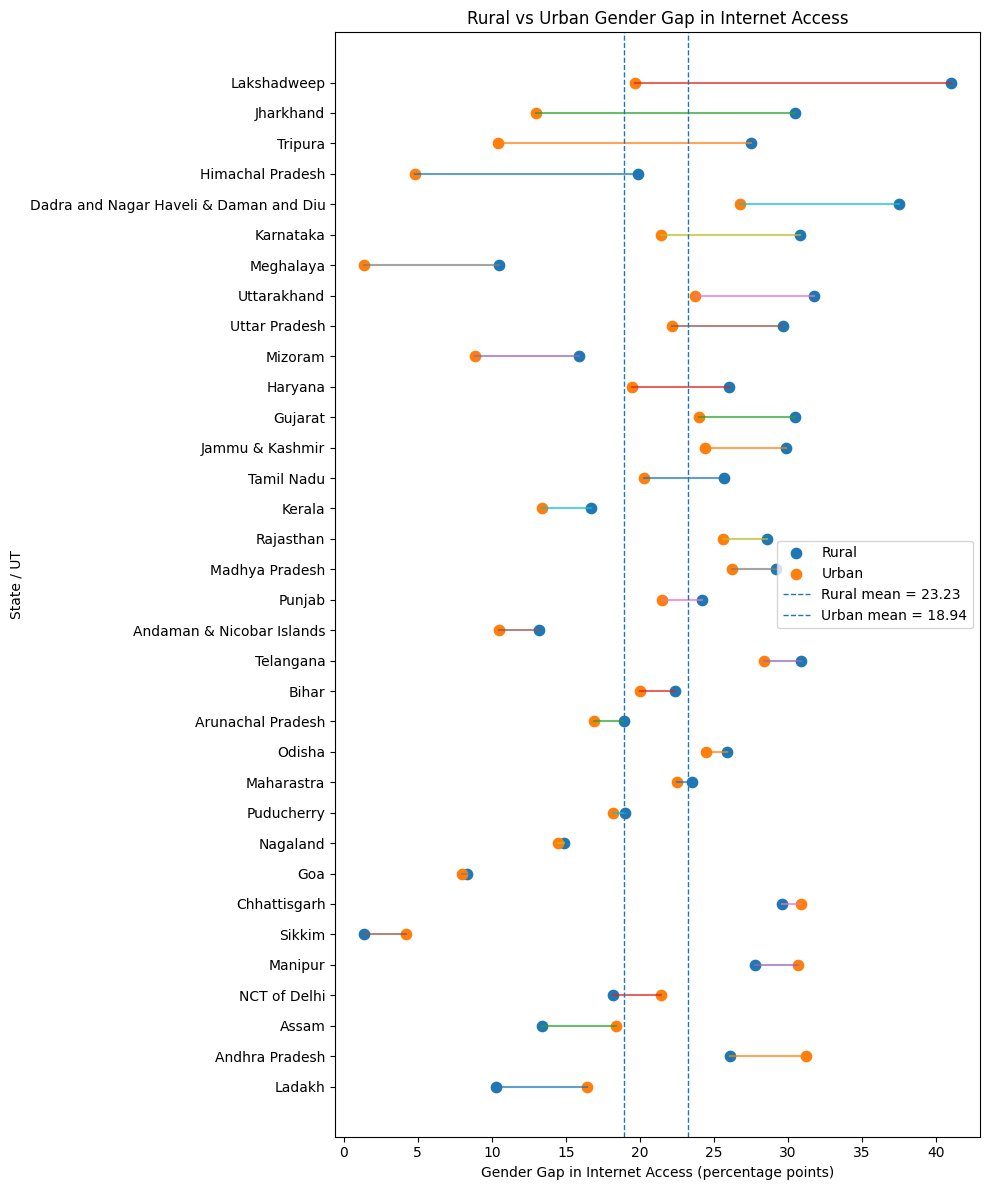

In [18]:
plot_df = test_df.sort_values(
    "Gap_Difference"
).copy()
y = np.arange(len(plot_df))

plt.figure(figsize=(10, 12))

# Connect Rural and Urban values
for i, (_, row) in enumerate(plot_df.iterrows()):
    plt.plot(
        [row["Gap_Urban"], row["Gap_Rural"]],
        [i, i],
        linewidth=1.5,
        alpha=0.7
    )

# Rural points
plt.scatter(
    plot_df["Gap_Rural"],
    y,
    s=55,
    label="Rural"
)

# Urban points
plt.scatter(
    plot_df["Gap_Urban"],
    y,
    s=55,
    label="Urban"
)

plt.yticks(
    y,
    plot_df["state_ut"]
)

plt.xlabel("Gender Gap in Internet Access (percentage points)")
plt.ylabel("State / UT")

plt.title(
    "Rural vs Urban Gender Gap in Internet Access"
)


plt.axvline(
    test_df["Gap_Rural"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Rural mean = {test_df['Gap_Rural'].mean():.2f}"
)

plt.axvline(
    test_df["Gap_Urban"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Urban mean = {test_df['Gap_Urban'].mean():.2f}"
)

plt.legend()

plt.tight_layout()
plt.show()

The gender digital divide in India is primarily compounded by the rural-urban divide. While internet access parity is generally better in urban centers (averaging a 19 point gap), rural communities face a systematically harsher gender barrier (23 point gap), with extreme regional disparities where rural women are disproportionately left behind

# 3 Econometric Driver Analysis (Multivariate OLS Regression)

<h2>1. Goal</h2>
To identify the state-level factors associated with women's Internet penetration in India using socioeconomic, financial-access, and technology-access indicators from NFHS-5.

Your dependent variable is:
Yi​=Women Internet Penetration

The explanatory variables are:
<ul>
<li>Female literacy</li>
<li>Women’s mobile ownership</li>
<li>Women’s bank-account ownership</li>
<li>Electricity access</li>
</ul>

<b>Key Idea</b>: When these factors are considered simultaneously, which ones are significantly associated with women's Internet penetration?

<h2>2. Hypothesis</h2>
<b>Null hypothesis</b>: None of the four explanatory variables has a statistically significant linear association with women's Internet penetration.

<b>Alternative hypothesis</b>: At least one of the explanatory variables has a statistically significant linear association with women's Internet penetration.

<h2>3. Why use this testing method?</h2>

<b>Why multiple linear regression?</b>

Becasue we have one continuous outcome and several potential explanatory variables.

The model is Women Interneti​=β0​+β1​Literacy​+β2​Mobile​+β3​Bank​+β4​Electricity access​+ϵ

<h2>4. Why the VIF test?</h2>
The explanatory variables may be related to each other.

If two or more predictors contain very similar information, the regression may have difficulty separating their individual effects.

VIF (Variance Inflation Factor) checks this multicollinearity.

The PLanne Threshold is: VIF < 5

<h2>Why the Breusch–Pagan test?</h2>
OLS assumes that the variance of the regression errors is reasonably constant across observations.

If the variance changes substantially between states, than it have heteroskedasticity.

### Step 1: prepare the regression dataset.

In [19]:
reg_vars = [
    "Women_Internet_pct_total",
    "female_literacy_pct_total",
    "Women_Mobile_Ownership_pct_total",
    "women_bank_account_pct_total",
    "Electricity_Access_total"
]

df_reg = df_nfhs[["state_ut"] + reg_vars].copy()

df_reg.head()

,state_ut,Women_Internet_pct_total,female_literacy_pct_total,Women_Mobile_Ownership_pct_total,women_bank_account_pct_total,Electricity_Access_total
0,Andaman & Nicobar Islands,34.8,86.0,80.8,89.2,97.6
1,Andhra Pradesh,21.0,68.6,48.9,81.8,99.5
2,Arunachal Pradesh,52.9,73.8,76.4,78.2,94.8
3,Assam,28.2,77.2,57.2,78.5,92.6
4,Bihar,20.6,57.8,51.4,76.7,96.3


In [20]:
df_reg[reg_vars].isna().sum()

Women_Internet_pct_total            0
female_literacy_pct_total           0
Women_Mobile_Ownership_pct_total    0
women_bank_account_pct_total        0
Electricity_Access_total            0
dtype: int64

### Step 2 — Check the relationships between predictors

In [21]:
corr_matrix = df_reg[[
    "female_literacy_pct_total",
    "Women_Mobile_Ownership_pct_total",
    "women_bank_account_pct_total",
    "Electricity_Access_total"
]].corr()

corr_matrix.round(3)

,female_literacy_pct_total,Women_Mobile_Ownership_pct_total,women_bank_account_pct_total,Electricity_Access_total
female_literacy_pct_total,1.000,0.764,-0.042,0.341
Women_Mobile_Ownership_pct_total,0.764,1.000,0.176,0.329
women_bank_account_pct_total,-0.042,0.176,1.000,0.285
Electricity_Access_total,0.341,0.329,0.285,1.000


<ul>
<li>Female literacy ↔ women's mobile ownership = 0.764 → relatively strong correlation.</li>
<li>Female literacy with electricity access = 0.341 → moderate.</li>
<li>Mobile ownership with electricity access = 0.329 → moderate.</li>
<li>Bank-account ownership has weak correlations with the other predictors.</li>
</ul>

### Step 3 — Calculate VIF

In [22]:
X = df_reg[[
    "female_literacy_pct_total",
    "Women_Mobile_Ownership_pct_total",
    "women_bank_account_pct_total",
    "Electricity_Access_total"
]].copy()

X = sm.add_constant(X)

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.round(3)

,Variable,VIF
0,const,1857.498
1,female_literacy_pct_total,2.754
2,Women_Mobile_Ownership_pct_total,2.685
3,women_bank_account_pct_total,1.229
4,Electricity_Access_total,1.260


Since all predictor VIFs < 5, we have no evidence of problematic multicollinearity under our chosen threshold.

### Step 5 — Fit the OLS regression

In [23]:
y = df_reg["Women_Internet_pct_total"]

X = df_reg[[
    "female_literacy_pct_total",
    "Women_Mobile_Ownership_pct_total",
    "women_bank_account_pct_total",
    "Electricity_Access_total"
]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     Women_Internet_pct_total   R-squared:                       0.676
Model:                                  OLS   Adj. R-squared:                  0.632
Method:                       Least Squares   F-statistic:                     15.62
Date:                      Tue, 22 Sep 2026   Prob (F-statistic):           5.15e-07
Time:                              09:33:03   Log-Likelihood:                -127.13
No. Observations:                        35   AIC:                             264.3
Df Residuals:                            30   BIC:                             272.0
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

### Step 7 — Breusch–Pagan test

In [24]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

bp_results = pd.Series(
    bp_test,
    index=[
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

bp_results

LM Statistic    1.727246
LM p-value      0.785763
F Statistic     0.389338
F p-value       0.814558
dtype: float64

The Breusch–Pagan test does not provide evidence of heteroskedasticity.
Therefore, the standard OLS standard errors can be retained for the main model, and HC3 robust standard errors are not required based on the Breusch–Pagan test.

## Current econometric findings

Model: Women's Internet penetration ~ Female literacy + Women's mobile ownership + Bank-account ownership + Electricity access

<b>Model fit:</b>
<ul>
<li>R² = 0.676</li>
<li>Adjusted R² = 0.632</li>
<li>F(4,30) = 15.62</li>
<li>Overall p < 0.001</li>
</ul>

<b>Multicollinearity:</b> All predictor VIFs < 5

<b>Heteroskedasticity:</b>
<ul>
<li>Breusch–Pagan p = 0.786</li>
<li>No evidence of heteroskedasticity</li>
</ul>

<b>Individual associations:</b>
<ul>
<li>Women's mobile ownership: β = 0.632, p = 0.002 → statistically significant</li>
<li>Female literacy: β = 0.327, p = 0.264 → not statistically significant</li>
<li>Bank-account ownership: β = −0.078, p = 0.774 → not statistically significant</li>
<li>Electricity access: β = 1.202, p = 0.144 → not statistically significant</li>
</ul>
<i><b>Note</b>: The coefficients are on different scales and are therefore not directly comparable as measures of relative strength.</i>

## Step 6: calculate standardized coefficients

In [25]:
predictors = [
    "female_literacy_pct_total",
    "Women_Mobile_Ownership_pct_total",
    "women_bank_account_pct_total",
    "Electricity_Access_total"
]

# Standardize predictors
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_reg[predictors]),
    columns=predictors,
    index=df_reg.index
)

# Standardize dependent variable
y_scaled = pd.Series(
    StandardScaler().fit_transform(
        df_reg[["Women_Internet_pct_total"]]
    ).ravel(),
    name="Women_Internet_pct_total",
    index=df_reg.index
)

X_scaled = sm.add_constant(X_scaled)

model_std = sm.OLS(y_scaled, X_scaled).fit()

# Results
standardized_results = pd.DataFrame({
    "Variable": predictors,
    "Standardized_Beta": model_std.params[predictors],
    "p_value": model_std.pvalues[predictors]
})

standardized_results.round(4)

,Variable,Standardized_Beta,p_value
female_literacy_pct_total,female_literacy_pct_total,0.1963,0.2643
Women_Mobile_Ownership_pct_total,Women_Mobile_Ownership_pct_total,0.5890,0.0017
women_bank_account_pct_total,women_bank_account_pct_total,-0.0335,0.7735
Electricity_Access_total,Electricity_Access_total,0.1752,0.1437


These standardized coefficients confirm the pattern from the original OLS.Because all variables have been standardized, their coefficients are now on the same scale.

Within this state-level NFHS-5 model:
<b>Women's mobile ownership shows the strongest observed standardized association with women's Internet penetration and is the only predictor statistically significant at the 5% level.</b>The other three variables have positive/negative estimated associations, but their p-values do not provide sufficient evidence of an independent association at the 5% level.

The state-level regression provides evidence that the selected socioeconomic and technology-access indicators jointly explain a substantial share of the variation in women's Internet penetration across Indian states and UTs. The model is statistically significant overall, explaining 67.6% of the variation in women's Internet access (Adjusted R² = 63.2%; F(4,30) = 15.62, p < 0.001).

Among the four explanatory variables, women's mobile ownership is the only variable showing a statistically significant independent association with women's Internet penetration (standardized β = 0.589, p = 0.002). Holding the other variables constant, states with higher women's mobile ownership tend to have higher women's Internet penetration.

Female literacy (β = 0.196, p = 0.264), bank-account ownership (β = −0.034, p = 0.774), and electricity access (β = 0.175, p = 0.144) do not show statistically significant independent associations in this model.

The diagnostic tests also support the regression specification: all predictor VIFs are below 5, indicating no problematic multicollinearity, and the Breusch–Pagan test is not significant (p = 0.786), providing no evidence of heteroskedasticity.